Saving medis.jpg to medis.jpg


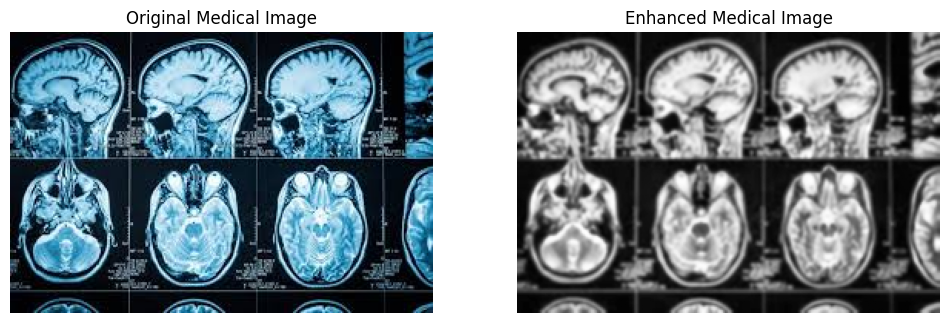

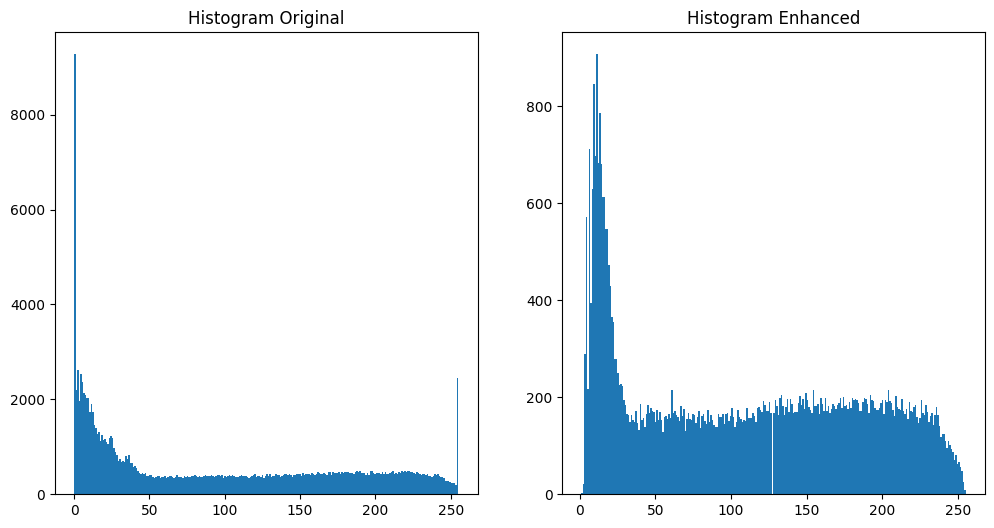


===== ENHANCEMENT REPORT =====

Modality :
X-ray

Method Used :
Gaussian Blur + CLAHE

Before Enhancement :
{'Mean Intensity': np.float64(92.47582712369598), 'Standard Deviation': np.float64(78.88973960709107), 'Contrast': np.uint8(254)}

After Enhancement :
{'Mean Intensity': np.float64(107.75578738201689), 'Standard Deviation': np.float64(77.01389693071982), 'Contrast': np.uint8(254)}


In [1]:
# =============================================
# PRAKTIKUM: ADAPTIVE MEDICAL IMAGE ENHANCEMENT
# =============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ===========================
# Fungsi Menghitung Metrics
# ===========================

def calculate_metrics(image):
    mean_intensity = np.mean(image)
    std_intensity = np.std(image)
    contrast = image.max() - image.min()

    return {
        "Mean Intensity": mean_intensity,
        "Standard Deviation": std_intensity,
        "Contrast": contrast
    }

# ===============================
# Fungsi Enhancement Citra Medis
# ===============================

def medical_image_enhancement(medical_image, modality='X-ray'):

    if len(medical_image.shape) == 3:
        medical_image = cv2.cvtColor(medical_image, cv2.COLOR_BGR2GRAY)

    original_metrics = calculate_metrics(medical_image)

    # =================================
    # Enhancement berdasarkan modalitas
    # =================================

    if modality == 'X-ray':
        blur = cv2.GaussianBlur(medical_image, (5,5), 0)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(blur)
        method = "Gaussian Blur + CLAHE"

    elif modality == 'MRI':
        median = cv2.medianBlur(medical_image, 5)
        enhanced = cv2.equalizeHist(median)
        method = "Median Filter + Histogram Equalization"

    elif modality == 'CT':
        sharpen_kernel = np.array([[0,-1,0],
                                   [-1,5,-1],
                                   [0,-1,0]])
        enhanced = cv2.filter2D(medical_image, -1, sharpen_kernel)
        method = "Sharpening Filter"

    elif modality == 'Ultrasound':
        enhanced = cv2.bilateralFilter(medical_image,9,75,75)
        method = "Bilateral Filter (Noise Reduction)"

    else:
        enhanced = medical_image
        method = "No enhancement"

    enhanced_metrics = calculate_metrics(enhanced)

    # ====================
    # Enhancement Report
    # ====================

    report = {
        "Modality": modality,
        "Method Used": method,
        "Before Enhancement": original_metrics,
        "After Enhancement": enhanced_metrics
    }

    return enhanced, report

# ========================
# Upload Gambar di Colab
# ========================

from google.colab import files
uploaded = files.upload()

# Ambil nama file yang diupload
image_name = list(uploaded.keys())[0]

# Baca gambar
image = cv2.imread(image_name)

# =================
# Pilih Modalitas
# =================

modality = 'X-ray'

# ======================
# Jalankan Enhancement
# ======================

enhanced_image, report = medical_image_enhancement(image, modality)

# ==================
# Tampilkan Gambar
# ==================

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Medical Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Enhanced Medical Image")
plt.imshow(enhanced_image, cmap='gray')
plt.axis('off')

plt.show()

# =====================
# Tampilkan Histogram
# =====================

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Histogram Original")
plt.hist(image.flatten(), bins=256)

plt.subplot(1,2,2)
plt.title("Histogram Enhanced")
plt.hist(enhanced_image.flatten(), bins=256)

plt.show()

# ==============================
# Tampilkan Enhancement Report
# ==============================

print("\n===== ENHANCEMENT REPORT =====")

for key, value in report.items():
    print(f"\n{key} :")
    print(value)